## Intro 

Pandas is a powerful open-source Python library used for data analysis, manipulation, and cleaning. It provides easy-to-use data structures and functions that help users work efficiently with structured data, such as tables, spreadsheets, and CSV files.

### The two main data structures in Pandas are:

- *Series*: A one-dimensional labeled array that can store any data type.
- *DataFrame*: A two-dimensional table with rows and columns, similar to an Excel spreadsheet or SQL table.

### Features 
- Read and write data from files (CSV, Excel, JSON, SQL, etc.)
- Clean and preprocess data (handle missing values, duplicates, etc.)
- Filter, sort, and group data
- Perform statistical analysis
- Merge and join datasets
- Work with time series data
- Visualize data with libraries like Matplotlib

### Series
1d labeled array capable of storing any data type, labeled=index

`series are vertical`

In [1]:
import pandas as pd;
import numpy as np;

In [2]:
labels = ['a', 'b', 'c']
my_list = [10, 20, 30]

arr = np.array([10, 20, 30])
d = {'a':10, 'b':20, 'c':30}

In [3]:
pd.Series(my_list)

0    10
1    20
2    30
dtype: int64

In [4]:
#custom index
pd.Series(my_list, index=labels)

a    10
b    20
c    30
dtype: int64

In [5]:
# np array works same
pd.Series(arr)

0    10
1    20
2    30
dtype: int32

In [6]:
#dict keys = index and values = data
pd.Series(d)

a    10
b    20
c    30
dtype: int64

### DataFrame
Combiing multiple series together


In [7]:
# with dict the col names will automaticaly provided
data = {
    'Name': ['John', 'Anna', 'Peter', 'Linda'],
    'Age': [28, 34, 29, 42],
    'City': ['New York', 'Paris', 'Berlin', 'London'],
    'Salary': [65000, 70000, 62000, 85000]
}


In [8]:
df = pd.DataFrame(data)

In [9]:
df

,Name,Age,City,Salary
0,John,28,New York,65000
1,Anna,34,Paris,70000
2,Peter,29,Berlin,62000
3,Linda,42,London,85000


In [10]:
# with list we need to provide col names manuallly
data_list = [
    ['John', 28, 'New York', 65000],
    ['Anna', 34, 'Paris', 70000],
    ['Peter', 29, 'Berlin', 62000],
    ['Linda', 42, 'London', 85000]
]

col_names = ["Names", "Age", "City", "Salary"]

In [11]:
pd.DataFrame(data_list, index=col_names)

,0,1,2,3
Names,John,28,New York,65000
Age,Anna,34,Paris,70000
City,Peter,29,Berlin,62000
Salary,Linda,42,London,85000


In [12]:
pd.DataFrame(data_list, columns=col_names)

,Names,Age,City,Salary
0,John,28,New York,65000
1,Anna,34,Paris,70000
2,Peter,29,Berlin,62000
3,Linda,42,London,85000


### Indexing
always use the col names as index

In [13]:
df

,Name,Age,City,Salary
0,John,28,New York,65000
1,Anna,34,Paris,70000
2,Peter,29,Berlin,62000
3,Linda,42,London,85000


In [14]:
df["Name"]

0     John
1     Anna
2    Peter
3    Linda
Name: Name, dtype: str

In [15]:
df[["Name", "City"]]

,Name,City
0,John,New York
1,Anna,Paris
2,Peter,Berlin
3,Linda,London


In [16]:
# adding a column
df["Desingnation"] = ["Dr", "Eng.", "Dr", "Eng."]

In [17]:
df

,Name,Age,City,Salary,Desingnation
0,John,28,New York,65000,Dr
1,Anna,34,Paris,70000,Eng.
2,Peter,29,Berlin,62000,Dr
3,Linda,42,London,85000,Eng.


In [18]:
# axis=0 row delete, axis=1, col delete
# df = df.drop("Desingnation", axis=1)
df.drop("Desingnation", axis=1, inplace=True)

In [19]:
df

,Name,Age,City,Salary
0,John,28,New York,65000
1,Anna,34,Paris,70000
2,Peter,29,Berlin,62000
3,Linda,42,London,85000


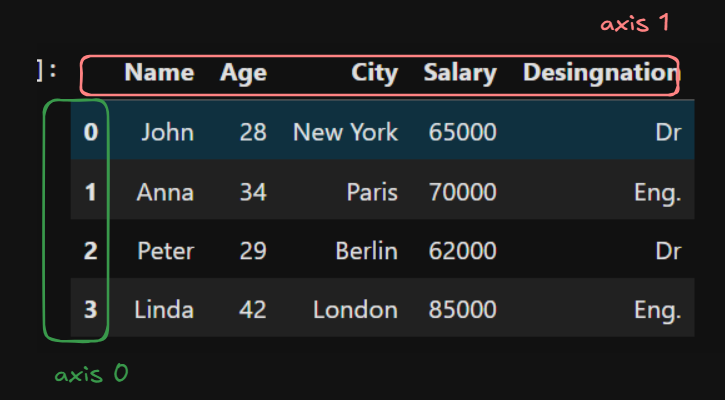


In [20]:
df.drop(["City", "Salary"], axis=1)

,Name,Age
0,John,28
1,Anna,34
2,Peter,29
3,Linda,42


In [21]:
df

,Name,Age,City,Salary
0,John,28,New York,65000
1,Anna,34,Paris,70000
2,Peter,29,Berlin,62000
3,Linda,42,London,85000


In [22]:
df.drop([1,2], axis=0)

,Name,Age,City,Salary
0,John,28,New York,65000
3,Linda,42,London,85000


In [23]:
df

,Name,Age,City,Salary
0,John,28,New York,65000
1,Anna,34,Paris,70000
2,Peter,29,Berlin,62000
3,Linda,42,London,85000


### Selecting a row

In [24]:
df.loc[0]   # series 


Name          John
Age             28
City      New York
Salary       65000
Name: 0, dtype: object

In [25]:
df.loc[[1, 2]]

,Name,Age,City,Salary
1,Anna,34,Paris,70000
2,Peter,29,Berlin,62000


### Selecting subset of rows and cols


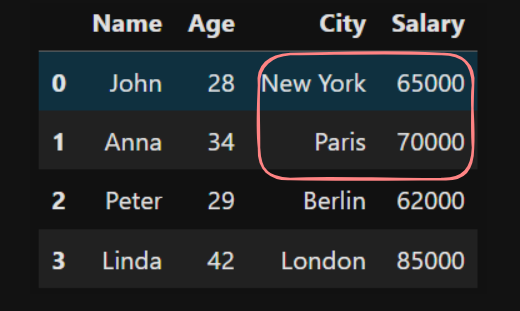

In [26]:
df

,Name,Age,City,Salary
0,John,28,New York,65000
1,Anna,34,Paris,70000
2,Peter,29,Berlin,62000
3,Linda,42,London,85000


In [27]:
df.loc[[0, 1]][["City", "Salary"]]

,City,Salary
0,New York,65000
1,Paris,70000


In [28]:
df.loc[[2, 3]][["Name", "Age"]]

,Name,Age
2,Peter,29
3,Linda,42


### Conditional Selection

same as numpy bool array thing

In [29]:
df

,Name,Age,City,Salary
0,John,28,New York,65000
1,Anna,34,Paris,70000
2,Peter,29,Berlin,62000
3,Linda,42,London,85000


In [30]:
# age is above 30
df[df["Age"] > 30]

,Name,Age,City,Salary
1,Anna,34,Paris,70000
3,Linda,42,London,85000


In [31]:
# age > 30 and from paris  [same as numpy]
df[(df["Age"] > 30) & (df["City"] == "Paris")]

,Name,Age,City,Salary
1,Anna,34,Paris,70000


# Missing Data

### Finding missing data

In [32]:
# np.nan = not a number / null
data = {
    'A': [1, 2, np.nan, 4, 5],
    'B': [1, 2, 3, 4, 5],
    'C': [1, 2, 3, np.nan, np.nan],
    'D': [1, np.nan, np.nan, np.nan, 5]
}

In [33]:
df = pd.DataFrame(data)
df

,A,B,C,D
0,1.0,1,1.0,1.0
1,2.0,2,2.0,NaN
2,NaN,3,3.0,NaN
3,4.0,4,NaN,NaN
4,5.0,5,NaN,5.0


In [34]:
# df.isna() --> return a dataframe containing t/f, if NaN -> true
df.isna()

,A,B,C,D
0,False,False,False,False
1,False,False,False,True
2,True,False,False,True
3,False,False,True,True
4,False,False,True,False


In [35]:
# to count which col has how many null
df.isna().sum()

A    1
B    0
C    2
D    3
dtype: int64

In [36]:
# to check if a col has any null val
df.isna().any()
# true means that col has a null val

A     True
B    False
C     True
D     True
dtype: bool

### Removing msiing data   -- happens in row wise

In [37]:
df

,A,B,C,D
0,1.0,1,1.0,1.0
1,2.0,2,2.0,NaN
2,NaN,3,3.0,NaN
3,4.0,4,NaN,NaN
4,5.0,5,NaN,5.0


In [38]:
# drops those rows which has a null
df.dropna()

,A,B,C,D
0,1.0,1,1.0,1.0


In [39]:
df

,A,B,C,D
0,1.0,1,1.0,1.0
1,2.0,2,2.0,NaN
2,NaN,3,3.0,NaN
3,4.0,4,NaN,NaN
4,5.0,5,NaN,5.0


In [40]:
#thresh=n   --> a row should have minimum n number of nonnull value
df.dropna(thresh=3)   #--> a row shoud have atlleast 3 nonnull val

,A,B,C,D
0,1.0,1,1.0,1.0
1,2.0,2,2.0,NaN
4,5.0,5,NaN,5.0


### filling null values 


In [41]:
df

,A,B,C,D
0,1.0,1,1.0,1.0
1,2.0,2,2.0,NaN
2,NaN,3,3.0,NaN
3,4.0,4,NaN,NaN
4,5.0,5,NaN,5.0


In [42]:
# df.fillna(-1)
df.fillna(0)


,A,B,C,D
0,1.0,1,1.0,1.0
1,2.0,2,2.0,0.0
2,0.0,3,3.0,0.0
3,4.0,4,0.0,0.0
4,5.0,5,0.0,5.0


In [43]:
#fill value depending on cols 
values = {"A" : 100, "B" : 200, "C": 300, "D": 400} 
df.fillna(value=values)

,A,B,C,D
0,1.0,1,1.0,1.0
1,2.0,2,2.0,400.0
2,100.0,3,3.0,400.0
3,4.0,4,300.0,400.0
4,5.0,5,300.0,5.0


# Merging, Concatination, Joining

In [44]:
employees = pd.DataFrame({
    'employee_id': [1, 2, 3, 4, 5],
    'name': ['John', 'Anna', 'Peter', 'Linda', 'Bob'],
    'department': ['HR', 'IT', 'Finance', 'IT', 'HR']
})

# DataFrame 2: Salary information
salaries = pd.DataFrame({
    'employee_id': [1, 2, 3, 6, 7],
    'salary': [60000, 80000, 65000, 70000, 90000],
    'bonus': [5000, 10000, 7000, 8000, 12000]
})

In [45]:
employees

,employee_id,name,department
0,1,John,HR
1,2,Anna,IT
2,3,Peter,Finance
3,4,Linda,IT
4,5,Bob,HR


In [46]:
salaries

,employee_id,salary,bonus
0,1,60000,5000
1,2,80000,10000
2,3,65000,7000
3,6,70000,8000
4,7,90000,12000


In [47]:
#on='col_name', on the basis on which we wanna merge
#how='inner'/'outer'/'left'/'right'
# inner -> only comon col value will be mergeed, both df should have the common col name
# outer -> on the basis of all values in that col
# 'left' -> the col from left table will have all its entries 
# 'right' -> the col from right table will have all its entries


pd.merge(employees, salaries, on='employee_id', how='inner')

,employee_id,name,department,salary,bonus
0,1,John,HR,60000,5000
1,2,Anna,IT,80000,10000
2,3,Peter,Finance,65000,7000


In [48]:
pd.merge(employees, salaries, on='employee_id', how='outer')

,employee_id,name,department,salary,bonus
0,1,John,HR,60000.0,5000.0
1,2,Anna,IT,80000.0,10000.0
2,3,Peter,Finance,65000.0,7000.0
3,4,Linda,IT,NaN,NaN
4,5,Bob,HR,NaN,NaN
5,6,NaN,NaN,70000.0,8000.0
6,7,NaN,NaN,90000.0,12000.0


In [49]:
df1 = pd.DataFrame({
    'A': ['A0', 'A1', 'A2'],
    'B': ['B0', 'B1', 'B2'],
    'C': ['C0', 'C1', 'C2'], 
    'D': ['d0', 'd1', 'd2'], 
})

df2 = pd.DataFrame({
    'A': ['A3', 'A4', 'A5'],
    'B': ['B3', 'B4', 'B5'],
    'C': ['C3', 'C4', 'C5']
})

In [50]:
df1

,A,B,C,D
0,A0,B0,C0,d0
1,A1,B1,C1,d1
2,A2,B2,C2,d2


In [51]:
df2

,A,B,C
0,A3,B3,C3
1,A4,B4,C4
2,A5,B5,C5


In [52]:
pd.concat([df1, df2])

,A,B,C,D
0,A0,B0,C0,d0
1,A1,B1,C1,d1
2,A2,B2,C2,d2
0,A3,B3,C3,NaN
1,A4,B4,C4,NaN
2,A5,B5,C5,NaN


In [53]:
# there is also join  -> based on index

df1 = pd.DataFrame({
    'name': ['Alice', 'Bob', 'Charlie']
}, index=[1, 2, 3])

# Second DataFrame
df2 = pd.DataFrame({
    'score': [85, 90, 75]
}, index=[2, 3, 4])

In [54]:
df1

,name
1,Alice
2,Bob
3,Charlie


In [55]:
df2

,score
2,85
3,90
4,75


In [56]:

df1.join(df2)

,name,score
1,Alice,NaN
2,Bob,85.0
3,Charlie,90.0


In [57]:
df2.join(df1)

,score,name
2,85,Bob
3,90,Charlie
4,75,NaN


### Group by and Aggregation

In [58]:
data = {
    'Category': ['A', 'B', 'A', 'B', 'A', 'B', 'A', 'B'],
    'Store': ['S1', 'S1', 'S2', 'S2', 'S1', 'S2', 'S2', 'S1'],
    'Sales': [100, 200, 150, 250, 120, 180, 200, 300],
    'Quantity': [10, 15, 12, 18, 8, 20, 15, 25],
    'Date': pd.date_range('2023-01-01', periods=8)  #periods=how many date
}

In [59]:
df = pd.DataFrame(data)
df

,Category,Store,Sales,Quantity,Date
0,A,S1,100,10,2023-01-01
1,B,S1,200,15,2023-01-02
2,A,S2,150,12,2023-01-03
3,B,S2,250,18,2023-01-04
4,A,S1,120,8,2023-01-05
5,B,S2,180,20,2023-01-06
6,A,S2,200,15,2023-01-07
7,B,S1,300,25,2023-01-08


In [60]:
#group by some common col values
#Q.grp by category and calculate sum of sales

# obj = df.groupby('Category') #-->obj
# for x, y in obj:
#     print(x, y)
# df.groupby('Category')['Sales']   #--> gives a object by groupby all common values

df.groupby('Category')["Sales"].sum()

Category
A    570
B    930
Name: Sales, dtype: int64

In [61]:
# group by stores and calculate sale
df.groupby('Store')['Sales'].sum()

Store
S1    720
S2    780
Name: Sales, dtype: int64

In [65]:
#groupy category and store to calculate the svalues
df.groupby(['Category', 'Store'])['Sales'].sum()

Category  Store
A         S1       220
          S2       350
B         S1       500
          S2       430
Name: Sales, dtype: int64

### Aggregation 
in Pandas is the process of combining multiple rows of data into a single,
summarized statistical value

- sum()
- mean()
- median()
- count()
- min/max()
- std() / var() -- standered deviation and varience

In [67]:
df

,Category,Store,Sales,Quantity,Date
0,A,S1,100,10,2023-01-01
1,B,S1,200,15,2023-01-02
2,A,S2,150,12,2023-01-03
3,B,S2,250,18,2023-01-04
4,A,S1,120,8,2023-01-05
5,B,S2,180,20,2023-01-06
6,A,S2,200,15,2023-01-07
7,B,S1,300,25,2023-01-08


In [77]:
df["Sales"].mean()

187.5

In [82]:
# multiple aggregaiton funtion
df["Sales"].agg(["sum", "mean", "median", "count"])

sum       1500.0
mean       187.5
median     190.0
count        8.0
Name: Sales, dtype: float64

###  Pivot table

In [83]:
data = {
    'Date': pd.date_range('2023-01-01', periods=20),
    'Product': ['A', 'B', 'C', 'D'] * 5,
    'Region': ['East', 'West', 'North', 'South', 'East', 'West', 'North', 'South', 'East', 'West',
               'North', 'South', 'East', 'West', 'North', 'South', 'East', 'West', 'North', 'South'],
    'Sales': np.random.randint(100, 1000, 20),
    'Units': np.random.randint(10, 100, 20),
    'Rep': ['John', 'Mary', 'Bob', 'Alice', 'John', 'Mary', 'Bob', 'Alice', 'John', 'Mary',
            'Bob', 'Alice', 'John', 'Mary', 'Bob', 'Alice', 'John', 'Mary', 'Bob', 'Alice']
}

In [85]:
df = pd.DataFrame(data)
df

,Date,Product,Region,Sales,Units,Rep
0,2023-01-01,A,East,351,40,John
1,2023-01-02,B,West,392,33,Mary
2,2023-01-03,C,North,228,65,Bob
3,2023-01-04,D,South,525,56,Alice
4,2023-01-05,A,East,592,16,John
5,2023-01-06,B,West,852,63,Mary
6,2023-01-07,C,North,676,36,Bob
7,2023-01-08,D,South,837,29,Alice
8,2023-01-09,A,East,183,44,John
9,2023-01-10,B,West,135,86,Mary


### A pivot table 
in pandas is a powerful data analysis tool used to summarize, aggregate, and reshape a large DataFrame into a clean, spreadsheet-style layout

In [96]:
df.pivot_table(values="Sales", index="Region", columns="Product", aggfunc="sum")

Product,A,B,C,D
Region,,,,
East,2726.0,NaN,NaN,NaN
North,NaN,NaN,2018.0,NaN
South,NaN,NaN,NaN,3171.0
West,NaN,2043.0,NaN,NaN


NaN values shows that... B product is not there in east regoin, nor in north, south,, or west same for all if we try to grab it

- by default the values are `mean`

In [90]:
df.pivot_table(values=["Sales", "Units"], index="Region", columns="Product", aggfunc="sum")

Sales                          Units                     
Product       A       B       C       D      A      B      C      D
Region                                                             
East     2726.0     NaN     NaN     NaN  255.0    NaN    NaN    NaN
North       NaN     NaN  2018.0     NaN    NaN    NaN  322.0    NaN
South       NaN     NaN     NaN  3171.0    NaN    NaN    NaN  244.0
West        NaN  2043.0     NaN     NaN    NaN  234.0    NaN    NaN

In [94]:
# first half is on the basis of sales and second half on the basis of unit

### Crosstab - same as pivit table, mostly used for count

In [106]:
pd.crosstab(df["Region"], df["Product"]) # takes two cols and counts how many products are there in each region

Product,A,B,C,D
Region,,,,
East,5,0,0,0
North,0,0,5,0
South,0,0,0,5
West,0,5,0,0


### Operations on DataFrames -- used in data preprocessing 

In [143]:
df = pd.DataFrame({
    'A': [1, 2, 3, 4, 5],
    'B': [10, 20, 30, 40, 50],
    'C': [100, np.nan, 300, 400, 500]
})
df

,A,B,C
0,1,10,100.0
1,2,20,NaN
2,3,30,300.0
3,4,40,400.0
4,5,50,500.0


In [112]:
df.shape

(5, 3)

In [114]:
df.columns

Index(['A', 'B', 'C'], dtype='str')

In [119]:
df.info()    #--> gives info about non null values aand more

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A       5 non-null      int64  
 1   B       5 non-null      int64  
 2   C       4 non-null      float64
dtypes: float64(1), int64(2)
memory usage: 252.0 bytes


In [121]:
df.describe()  # discribe each cols

,A,B,C
count,5.000000,5.000000,4.000000
mean,3.000000,30.000000,325.000000
std,1.581139,15.811388,170.782513
min,1.000000,10.000000,100.000000
25%,2.000000,20.000000,250.000000
50%,3.000000,30.000000,350.000000
75%,4.000000,40.000000,425.000000
max,5.000000,50.000000,500.000000


In [141]:
# broadcasting possible
df['A'] + 10

0    31
1    32
2    33
3    34
4    35
Name: A, dtype: int64

In [144]:
# to apply a funtion on each value
def addTen(n):
    return n + 10

df["A"] = df["A"].apply(addTen)
df

,A,B,C
0,11,10,100.0
1,12,20,NaN
2,13,30,300.0
3,14,40,400.0
4,15,50,500.0


In [146]:
df

,A,B,C
0,11,10,100.0
1,12,20,NaN
2,13,30,300.0
3,14,40,400.0
4,15,50,500.0


In [147]:
df["A"].apply(lambda x : x*x)

0    121
1    144
2    169
3    196
4    225
Name: A, dtype: int64